In [1]:
import sys
sys.path.append('../')
sys.path.append('../../')
import pydicom
from IPython.display import clear_output
import time
import math

from pydicom.data import get_testdata_file
from pydose_rt import ModelConfig
import numpy as np
from rt_utils import RTStructBuilder
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, rotate
from pydose_rt import DoseEngine
from pydose_rt.utils.data_loading import load_rtp_data
import SimpleITK as sitk
import torch
from itertools import permutations

In [2]:
ct_folder = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21/"
rtplan_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21_plans/CONFORM/RP1.2.752.243.1.1.20250814145813080.6700.31221.dcm"
# rtdose_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21_plans/CONFORM/RD1.2.752.243.1.1.20250814145813084.8000.80086.dcm" # Left beam
rtdose_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21_plans/CONFORM/RD1.2.752.243.1.1.20250814145813081.7000.75851.dcm" # All beams
# Load CT

ct_image, rt_doses, masks, mlcs = load_rtp_data(ct_folder, dose_path=[rtdose_path], plan_path=[rtplan_path], scaling=400)
dose_volume = sitk.GetArrayFromImage(list(rt_doses.values())[0])
ct_volume = sitk.GetArrayFromImage(ct_image)
external_mask = sitk.GetArrayFromImage(masks["External"])
ct_volume = np.where(external_mask, ct_volume, -1000.0)
ct_spacing = [ct_image.GetSpacing()[0], ct_image.GetSpacing()[1], ct_image.GetSpacing()[2]]
ct_shape = ct_volume.shape

In [3]:
config = ModelConfig(preset="umea",
                     ct_array_shape=ct_shape, 
                     resolution=ct_spacing, 
                     field_size=(400, 400), 
                     number_of_cps=4, 
                     starting_angle=0.0)

[2.0, 2.0, 2.0]


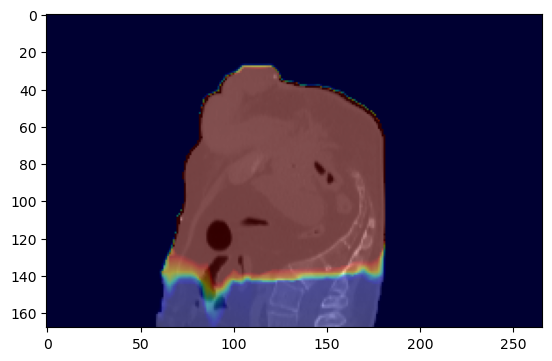

In [4]:
print(ct_spacing)
plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2], alpha=0.4, cmap='jet', vmax=0.01)

In [5]:
leafs = np.concatenate([mlcs[0][0], mlcs[2][0], mlcs[1][0], mlcs[3][0]], 2)
mus = 0.01 * np.concatenate([mlcs[0][1], mlcs[2][1], mlcs[1][1], mlcs[3][1]], 1)
ct_slices = np.array(np.expand_dims(ct_volume, 0), dtype=np.float32)
dose_layer = DoseEngine(config, 15, permute_ct=False, leafs_centered=True)
dose_pred = dose_layer(torch.tensor(np.abs(np.array(leafs)), dtype=torch.float32, device='cuda'), torch.tensor(np.array(mus), dtype=torch.float32, device='cuda'), ct_image=torch.tensor(ct_slices, dtype=torch.float32, device='cuda')).cpu().detach().numpy()[0, ...]

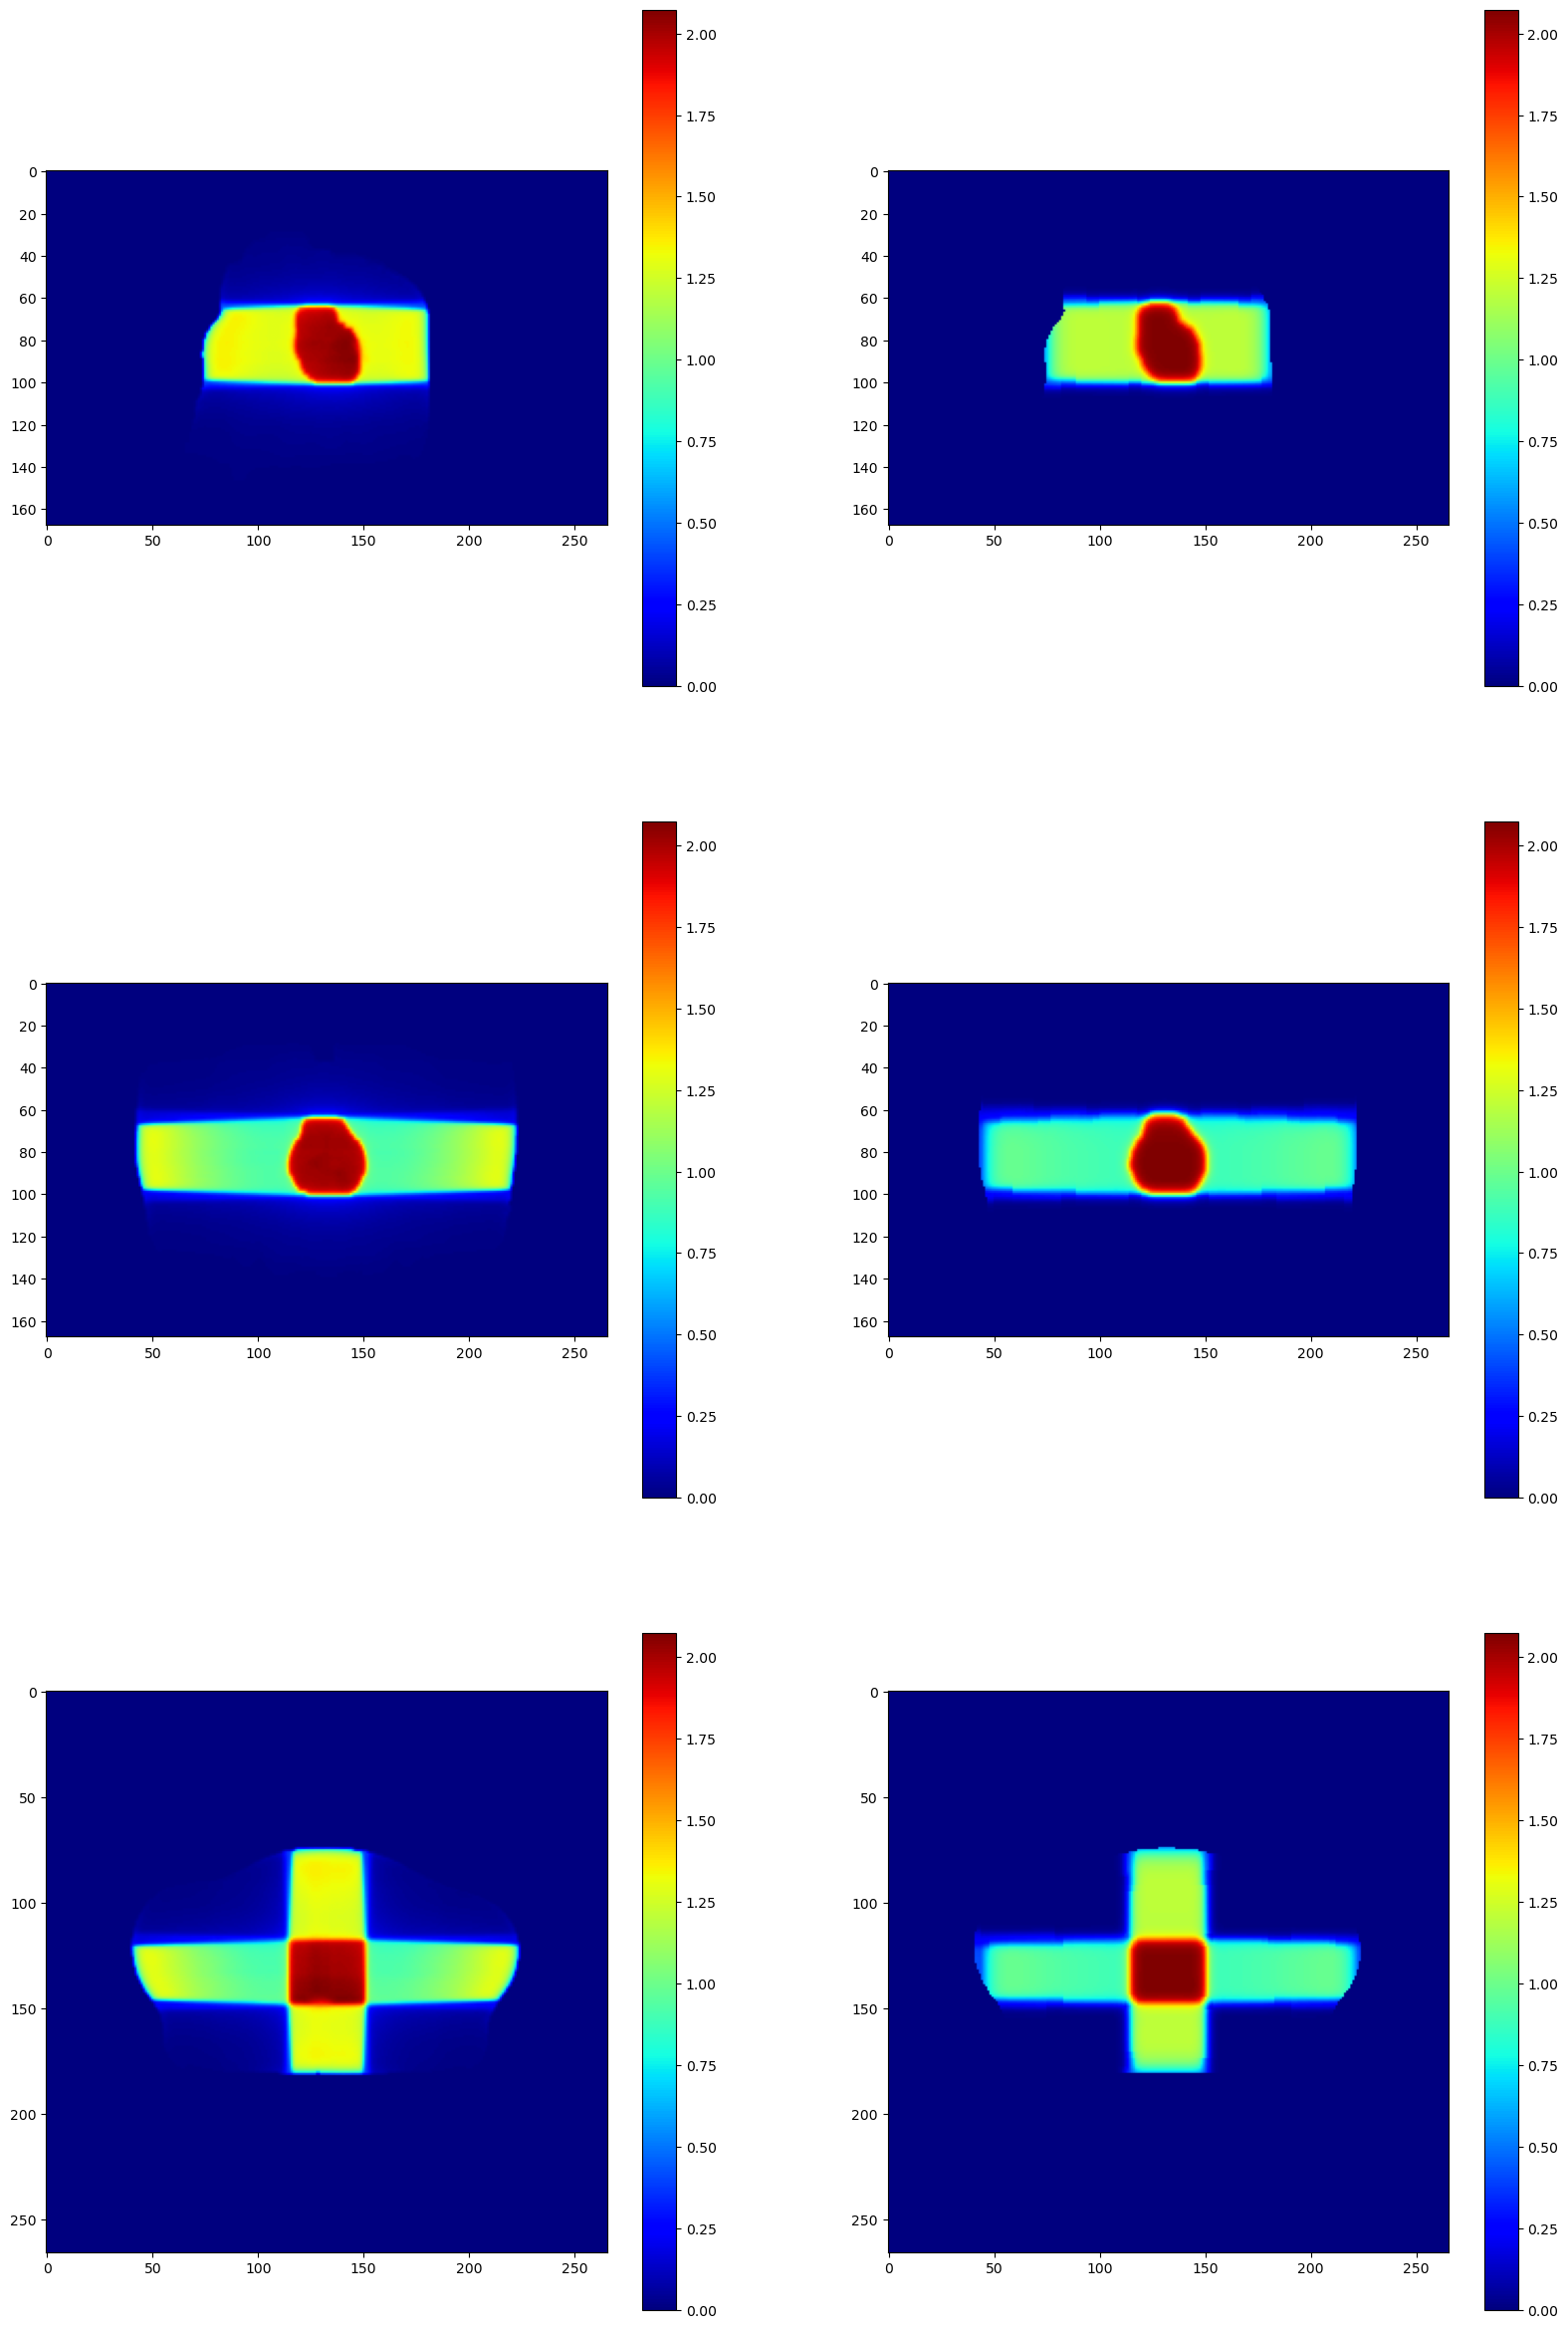

In [6]:
dose_plot = np.where(external_mask, dose_pred, 0)
pred_max = np.max(dose_plot)
resampled_ct = ct_image
dose_max = np.max(dose_volume)
dose_plot = dose_plot * dose_max / pred_max
pred_max = np.max(dose_plot)
alpha = 1.0
plt.figure(figsize=(20, 30))
plt.subplot(321)
# plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(322)
# plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_plot[:, :, ct_shape[2] // 2], cmap='jet', vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(323)
# plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(dose_volume[:, ct_shape[1] // 2, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(324)
# plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(dose_plot[:, ct_shape[1] // 2, :], cmap='jet', vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(325)
# plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(dose_volume[ct_shape[0] // 2, :, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(326)
# plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(dose_plot[ct_shape[0] // 2, :, :], cmap='jet', vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.show()

(168, 266, 266)


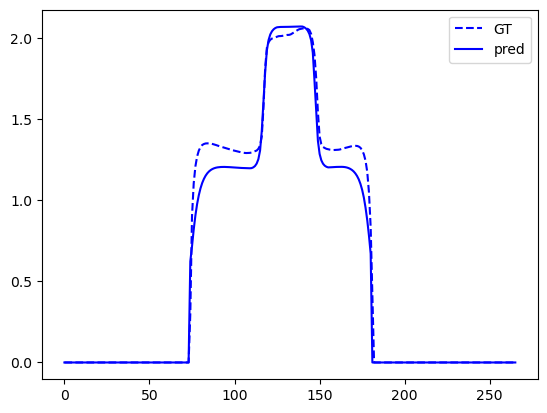

In [7]:
print(dose_volume.shape)
plt.plot(dose_volume[ct_shape[0] // 2, :, ct_shape[2] // 2], color='blue', label="GT", linestyle='--')
plt.plot(dose_plot[ct_shape[0] // 2, :, ct_shape[2] // 2], color='blue', label="pred")
plt.legend()
plt.show()

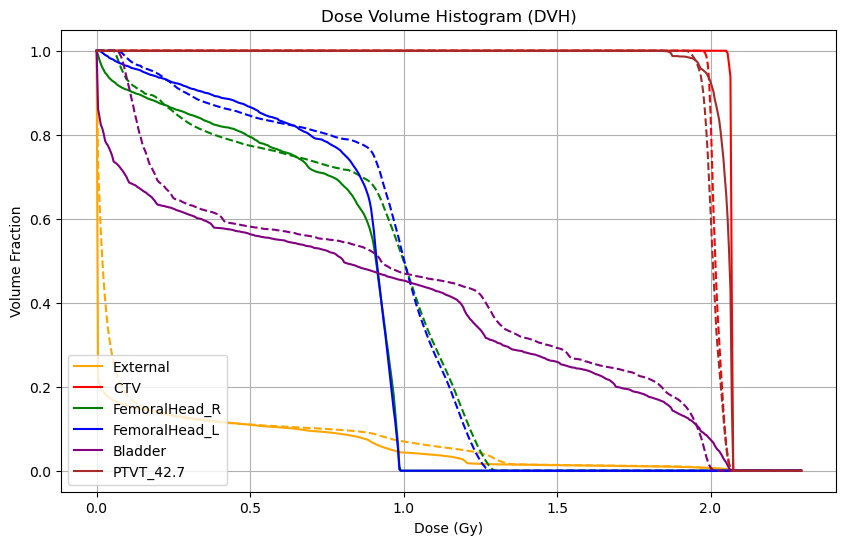

In [8]:
bins = np.linspace(0, 2.3, 500)

roi_colors = {
    "PTV": "orange",
    "ROI1": "red",
    "ROI2": "green",
    "ROI3": "blue",
    "ROI4": "purple",
    "ROI5": "brown",
    "ROI6": "black",
}

plt.figure(figsize=(10, 6))
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    dose_pred = dose_plot[np.array(sitk.GetArrayFromImage(masks[roi_name]), dtype=np.bool_)]
    dose_gt = dose_volume[np.array(sitk.GetArrayFromImage(masks[roi_name]), dtype=np.bool_)]


    # Compute the histogram
    hist, bin_edges = np.histogram(dose_gt, bins=bins, density=False)
    cumulative_hist = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
    cumulative_hist_normalized = (
        cumulative_hist / cumulative_hist.max()
    )  # Normalize
    plt.plot(
        bin_edges[:-1],
        cumulative_hist_normalized,
        label=None,
        linestyle='--',
        color=color,
    )

    # Compute the histogram
    hist, bin_edges = np.histogram(dose_pred, bins=bins, density=False)
    cumulative_hist = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
    cumulative_hist_normalized = (
        cumulative_hist / cumulative_hist.max()
    )  # Normalize
    plt.plot(
        bin_edges[:-1],
        cumulative_hist_normalized,
        label=roi_name,
        color=color,
    )

plt.xlabel("Dose (Gy)")
plt.ylabel("Volume Fraction")
plt.title("Dose Volume Histogram (DVH)")
plt.legend(loc='lower left')
plt.grid(True)

In [9]:
dose_plot_masked = dose_plot[np.array(sitk.GetArrayFromImage(masks["External"]), dtype=np.bool_)]
dose_gt_masked = dose_volume[np.array(sitk.GetArrayFromImage(masks["External"]), dtype=np.bool_)]
print(np.mean(np.abs(dose_plot_masked - dose_gt_masked) / dose_gt_masked))

0.8532005


In [10]:
dose_plot_masked = dose_plot[np.array(sitk.GetArrayFromImage(masks["PTVT_42.7"]), dtype=np.bool_)]
dose_gt_masked = dose_volume[np.array(sitk.GetArrayFromImage(masks["PTVT_42.7"]), dtype=np.bool_)]
print(np.mean(np.abs(dose_plot_masked - dose_gt_masked) / dose_gt_masked))

0.023503022


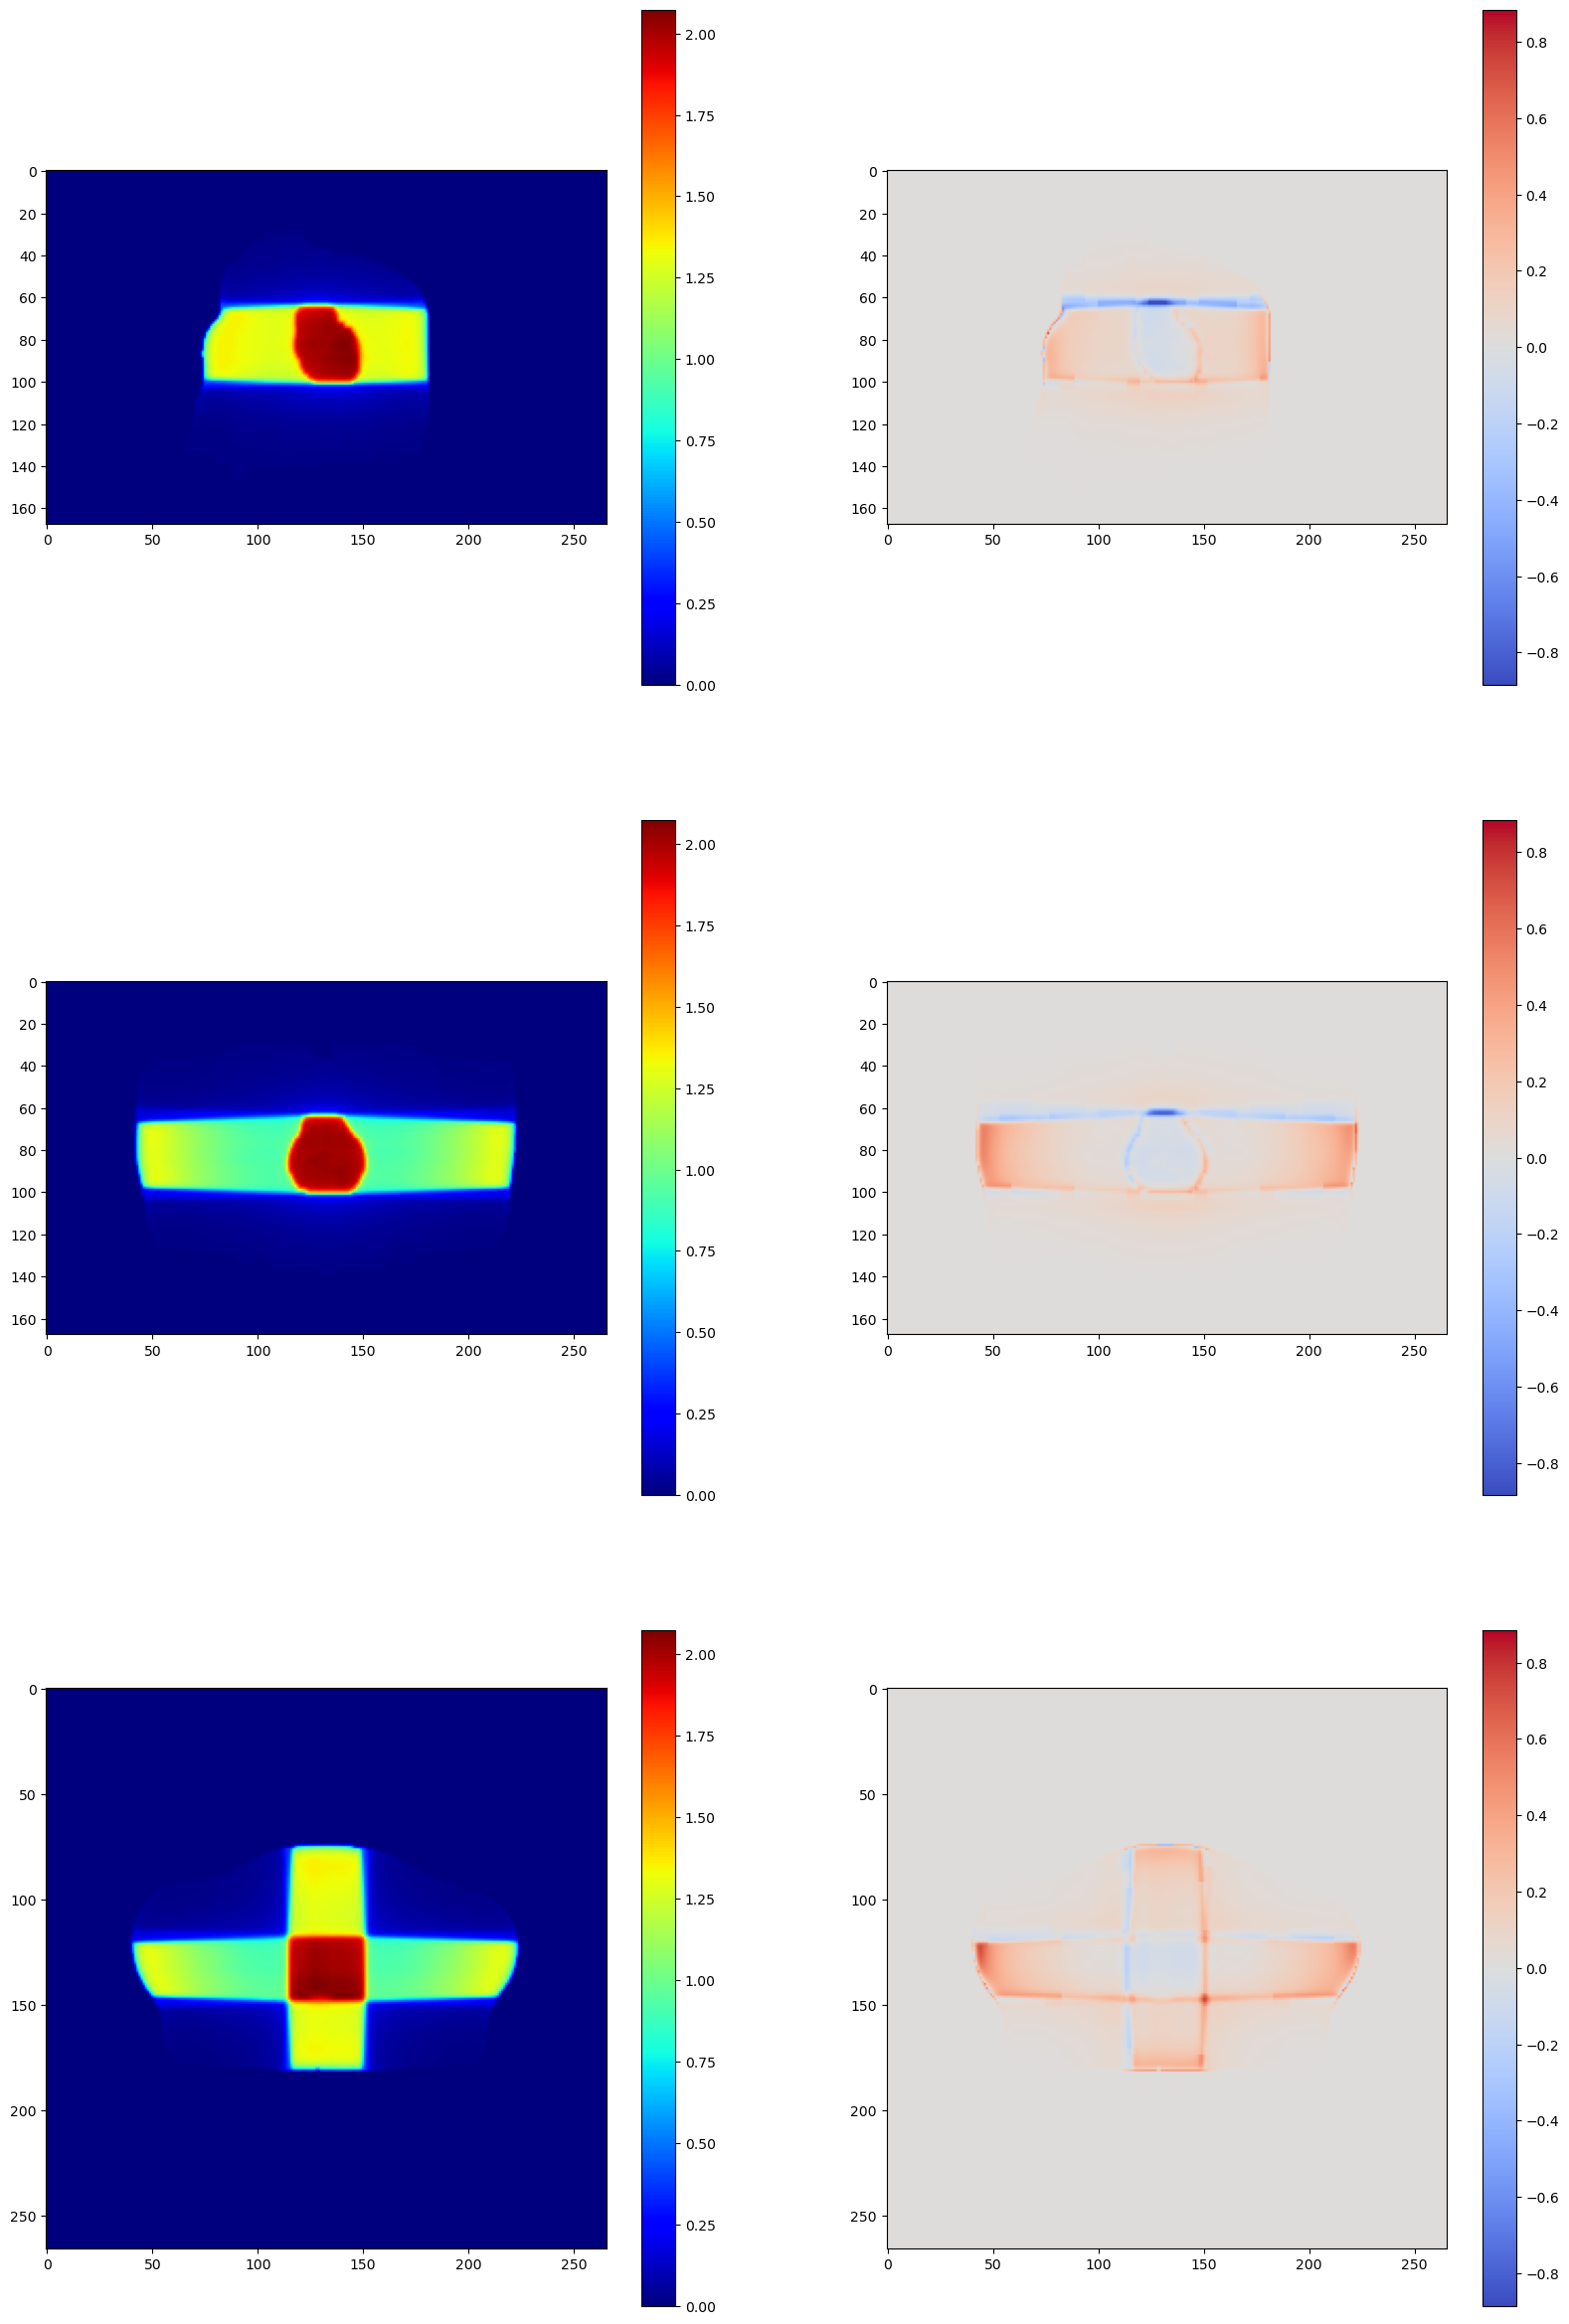

In [11]:
error_plot = dose_volume - dose_plot
scale = 1.0
pred_max = scale*np.max(error_plot)
pred_min = -scale*np.max(error_plot)
resampled_ct = ct_image
dose_max = np.max(dose_volume)
alpha = 1.0
plt.figure(figsize=(20, 30))
plt.subplot(321)
plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(322)
plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(error_plot[:, :, ct_shape[2] // 2], cmap='coolwarm', vmin=pred_min, vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(323)
plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(dose_volume[:, ct_shape[1] // 2, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(324)
plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(error_plot[:, ct_shape[1] // 2, :], cmap='coolwarm', vmin=pred_min, vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(325)
# plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(dose_volume[ct_shape[0] // 2, :, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(326)
# plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(error_plot[ct_shape[0] // 2, :, :], cmap='coolwarm', vmin=pred_min, vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.show()